# **PART 1: DATA LOADING AND OVERVIEW**


In [5]:
# IMPORTING REQUIRED LIBRARIES
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn as skl
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# loading the dataset into the panda dataframe.
df = pd.read_csv(r"C:\Users\ADMIN\Downloads\Data science project datasets\employees.csv")

# first ten rows
print(f'First ten rows of the dataset:\n')
display(df.head(10))

# datset shape
print(f'\nshape: {df.shape[0]} rows x {df.shape[1]} columns')

# data types
print(f'\ncolumn names and data types: \n{df.dtypes}')

# summary statistics for numerical columns
print('\nsummary statistics for numerical columns:')
print(df.describe())

# identify missing values per column
print('\nMissing values per column:')
print(df.isnull().sum())

# identify duplicate rows
print('\nDuplicate rows:')
print(df.duplicated().sum())

print("""\n OBSERVATIONS ---> PART 1:
THE DATASET CONTAINS A DIMENSION OF 205 ROWS AND 7 COLUMNS
 STATISTICAL ANALYSIS THE SALARY RANGES FROM 30,000 TO 136,200 WITH AN AVERAGE
 OF 74,341, THE BONUS% RANGES FROM 2.1% TO 24.9% WITH MEAN OF 13.09%
COLUMNS GENDER, TEAM, BONUS% BOTH HAVE MISSING VALUES 5 DUPLICATES ARE SEEN
""")

First ten rows of the dataset:



,Name,Gender,Team,Salary,Bonus %,Senior Management,Start Date
0,Grace Brown,Female,Sales,30000.0,22.2,True,2016-03-22
1,Nina White,Female,Engineering,55200.0,9.9,False,2011-09-07
2,Karen Davis,Female,Finance,72600.0,20.9,False,2006-04-25
3,Nina Jones,Male,Marketing,73800.0,4.5,False,2017-10-21
4,Grace Moore,Male,Operations,80700.0,21.5,False,2018-05-15
5,Sam Miller,Male,Marketing,81700.0,4.9,False,2021-02-01
6,Karen Taylor,Female,Marketing,108400.0,11.1,True,2013-04-12
7,Xander Jones,Male,Operations,81900.0,20.3,True,2021-02-26
8,David Davis,Male,Sales,68100.0,5.4,True,2012-02-07
9,Xander Williams,Male,Finance,39800.0,7.3,False,2006-04-15



shape: 205 rows x 7 columns

column names and data types: 
Name                  object
Gender                object
Team                  object
Salary               float64
Bonus %              float64
Senior Management       bool
Start Date            object
dtype: object

summary statistics for numerical columns:
              Salary     Bonus %
count     205.000000  197.000000
mean    74341.463415   13.090355
std     21768.354613    6.637575
min     30000.000000    2.100000
25%     60600.000000    7.100000
50%     73300.000000   12.400000
75%     87900.000000   18.600000
max    136200.000000   24.900000

Missing values per column:
Name                  0
Gender               12
Team                 10
Salary                0
Bonus %               8
Senior Management     0
Start Date            0
dtype: int64

Duplicate rows:
5

 OBSERVATIONS ---> PART 1:
THE DATASET CONTAINS A DIMENSION OF 205 ROWS AND 7 COLUMNS
 STATISTICAL ANALYSIS THE SALARY RANGES FROM 30,000 TO 136,200 WITH 

# **PART 2 HANDLE MISSING VALUES**

In [6]:
#step 1: display the number of missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())


#step 2: fill categorical missing value with unknown to maintain row number
df['Team'] = df['Team'].fillna('unknown')
df['Gender'] = df['Gender'].fillna('unknown')


#step 3: fill numerical missing values with median
median_bonus = df['Bonus %'].median()
df['Bonus %'] = df['Bonus %'].fillna(median_bonus)
print(f"\nBonus % median used for imputation: {median_bonus:.3f}")

# remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Rows removed (duplicates): {before - len(df)}")
print(f"Rows remaining: {len(df)}")

#step 4: verify the number of missing values after cleaning
print("\nmissing values after cleaning")
print(f'{df.isnull().sum()}')

print("""\n OBSERVATIONS ---> PART 2:
Categorical nulls gender and team filled with unknown to preserve the rows
rather than dropping them bonus % filled with the median because it
it can be skewed if mean was used due to its robustness to outliers
5 duplicates were removed zero missing value """)

Missing values before cleaning:
Name                  0
Gender               12
Team                 10
Salary                0
Bonus %               8
Senior Management     0
Start Date            0
dtype: int64

Bonus % median used for imputation: 12.400
Rows removed (duplicates): 5
Rows remaining: 200

missing values after cleaning
Name                 0
Gender               0
Team                 0
Salary               0
Bonus %              0
Senior Management    0
Start Date           0
dtype: int64

 OBSERVATIONS ---> PART 2:
Categorical nulls gender and team filled with unknown to preserve the rows
rather than dropping them bonus % filled with the median because it
it can be skewed if mean was used due to its robustness to outliers
5 duplicates were removed zero missing value 


# **PART 3: DATA CLEANING AND FEATURE ENGINEERING**

In [7]:

# step 1: convert columns start Date to datetime senoir management to bool
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['Senior Management'] = df['Senior Management'].astype(bool)
df.dtypes

# step 2: feature engineering adding a new column
df['Start Year'] = df['Start Date'].dt.year.astype(int)
df['Year Of Service'] = 2025 - df['Start Year']

# step 3: encode categorial columns as category data types
df['Team'] = df['Team'].astype('category')
df['Gender'] = df['Gender'].astype('category')
display(df.dtypes)
df.head()

print("""\nObservation ---> part 3
 1. start year is extracted directly from the date.
 2. year of service calculated as 2025 - start year
 3. gender and team data types changed to category data type reduces memory usage
 and makes group by operation easier
 4. start date converted to datetime data type unlocks the.dt accessor for year
 and month extraction""")


Name                         object
Gender                     category
Team                       category
Salary                      float64
Bonus %                     float64
Senior Management              bool
Start Date           datetime64[ns]
Start Year                    int64
Year Of Service               int64
dtype: object


Observation ---> part 3
 1. start year is extracted directly from the date.
 2. year of service calculated as 2025 - start year
 3. gender and team data types changed to category data type reduces memory usage
 and makes group by operation easier
 4. start date converted to datetime data type unlocks the.dt accessor for year
 and month extraction


# **PART 4: EDA**
#  A: Univariate Analysis
 invovles one variable mainly to understand the datashape, central tendency and outliers within the dataset the common visualizers are histograms and box-plots and bar-charts

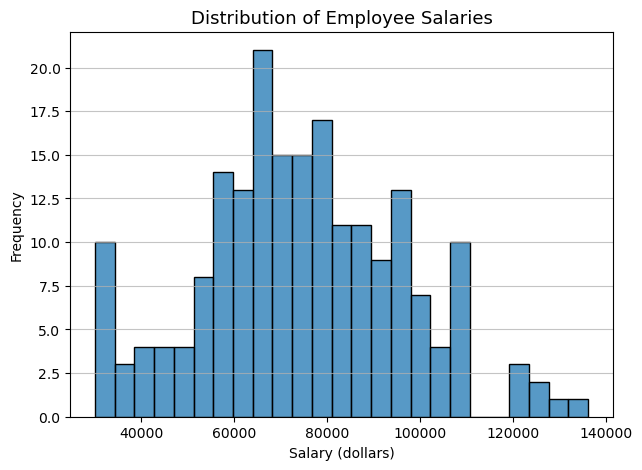

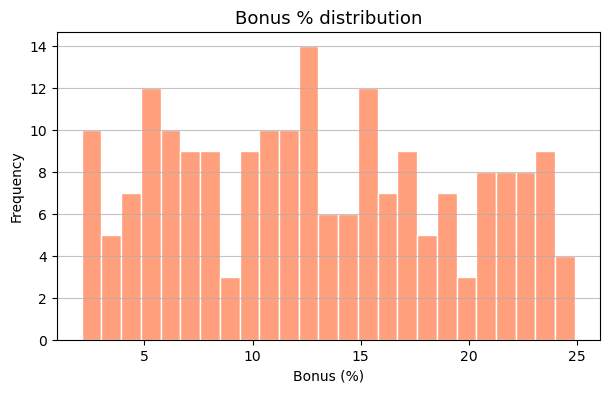

In [8]:
# a numerical variable we check at the data distribution use histograms to see
# the overall distribution and shape of data.
# STEP 1: plot a histogram for salary and bonus%
plt.figure(figsize=(7, 5))
sns.histplot(df['Salary'], bins=25, )
plt.title('Distribution of Employee Salaries', fontsize=13)
plt.xlabel('Salary (dollars)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()
print("")

plt.figure(figsize=(7,4 ))
sns.histplot(df['Bonus %'],bins=25,color = 'coral',edgecolor = 'white')
plt.title('Bonus % distribution', fontsize=13)
plt.xlabel('Bonus (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


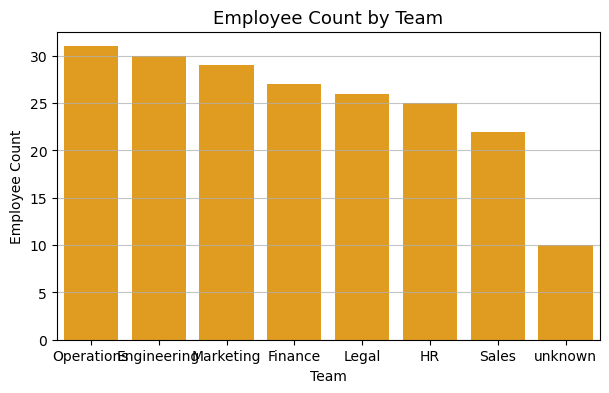

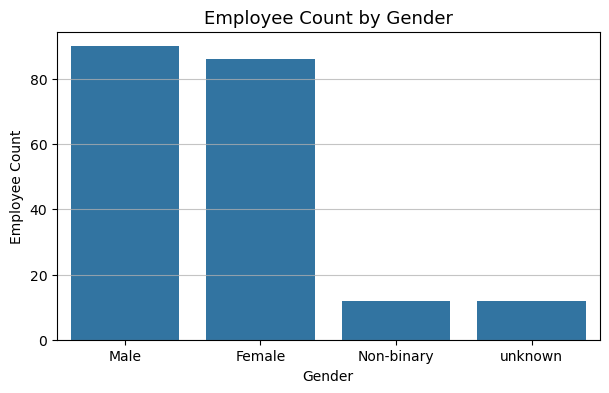

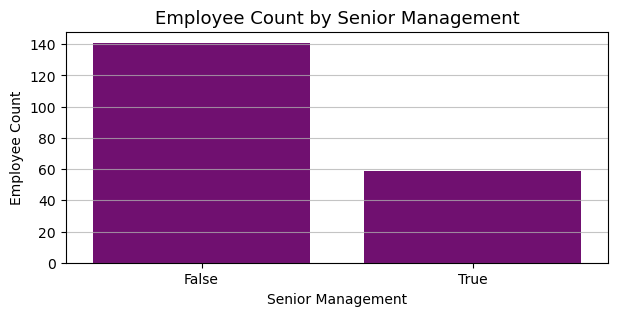



Observations — Part 4A:
- Salary follows a roughly normal distribution centred near 90k, with a slight right skew — a few employees earn close to 150k.
- Bonus % is uniformly distributed** between ~1% and 20%, suggesting bonuses are not tightly linked to salary level.
- Gender: Male slightly outnumbers Female; a small `Unknown` group appears from imputation.
- Team: Client Services is the largest team; Distribution is the smallest.
- Senior Management: Approximately 47% are Senior (469 of 1,000) — a fairly balanced split.


In [9]:
# step 2 plot barcharts for team gender and senoir management
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Team', order=df['Team'].value_counts().index,color = 'orange')
plt.title('Employee Count by Team', fontsize=13)
plt.xlabel('Team')
plt.ylabel('Employee Count')
plt.grid(axis='y', alpha=0.75)
plt.show()
print("")

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Gender', order=df['Gender'].value_counts().index)
plt.title('Employee Count by Gender', fontsize=13)
plt.xlabel('Gender')
plt.ylabel('Employee Count')
plt.grid(axis='y', alpha=0.75)
plt.show()
print("")

plt.figure(figsize=(7, 3))
sns.countplot(data=df, x='Senior Management', order=df['Senior Management'].value_counts().index,color = 'purple')
plt.title('Employee Count by Senior Management', fontsize=13)
plt.xlabel('Senior Management')
plt.ylabel('Employee Count')
plt.grid(axis='y', alpha=0.75)
plt.show()
print("")

print("""\nObservations — Part 4A:
- Salary follows a roughly normal distribution centred near 90k, with a slight right skew — a few employees earn close to 150k.
- Bonus % is uniformly distributed** between ~1% and 20%, suggesting bonuses are not tightly linked to salary level.
- Gender: Male slightly outnumbers Female; a small `Unknown` group appears from imputation.
- Team: Client Services is the largest team; Distribution is the smallest.
- Senior Management: Approximately 47% are Senior (469 of 1,000) — a fairly balanced split.""")

# PART 4B: BIVARIATE ANALYSIS
invovles 2 variables simultanously to see if there is a relationship, correlation or a dependency between them Scatter plots, Grouped bar charts, Side-by-side box plots are the visualizers

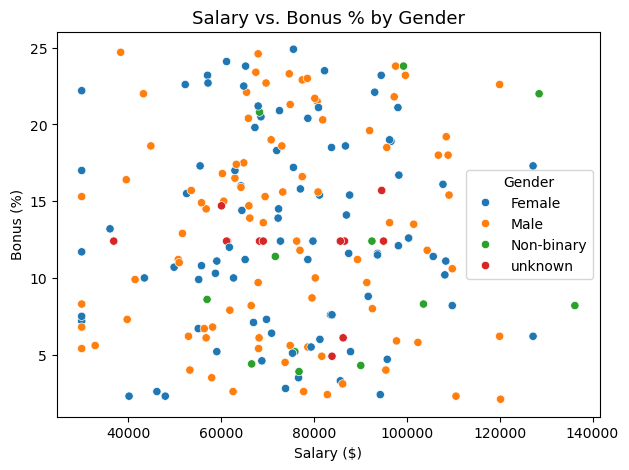

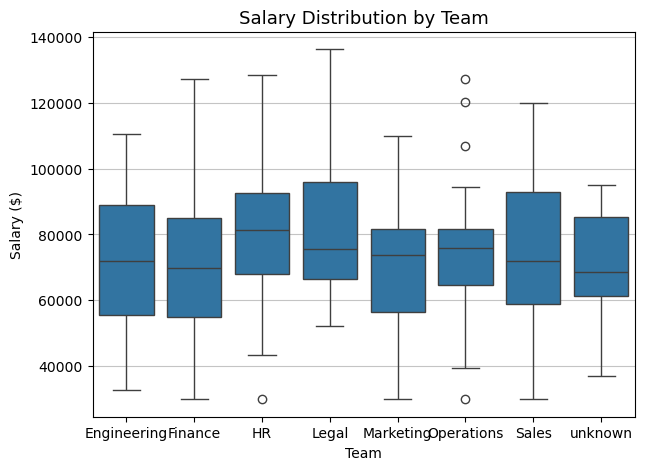

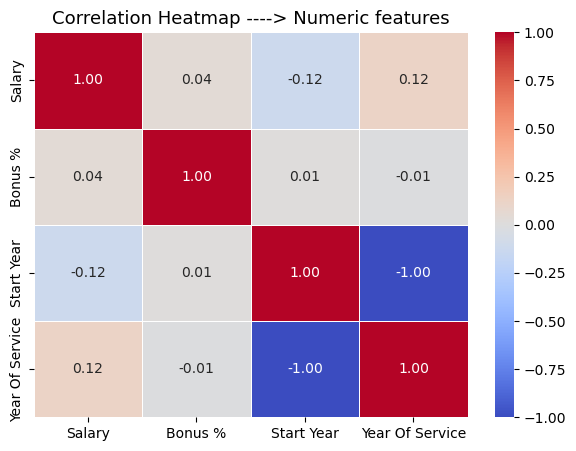


Bivariate Summary:

- **Salary vs. Bonus % by Gender (Scatter Plot):** No strong linear correlation is observed between Salary and Bonus %. Both high and low salaries are associated with a wide range of bonus percentages. Gender does not appear to be a significant factor in this relationship, with all gender categories showing similar distributions.

- **Salary Distribution by Team (Box Plot):** Salary distributions vary across teams:
 - **Legal** and **HR** teams show slightly higher median salaries and a broader spread, particularly for Legal which has some of the highest salaries.
 - **Marketing** and **Sales** teams generally have slightly lower median salaries and a more concentrated distribution.
 - **Operations** and **Engineering** have comparable median salaries and interquartile ranges.
 - Outliers (individual salaries significantly above or below the typical range) are present in several teams, indicating some highly paid or lower-paid individuals within those groups.

- **

In [10]:
 # step 1: scatter plot of salary vs Bonus% colored b gender

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Salary', y='Bonus %', hue='Gender')
plt.title('Salary vs. Bonus % by Gender', fontsize=13)
plt.xlabel('Salary ($)')
plt.ylabel('Bonus (%)')
plt.show()
print("")

# step 2 box plot salary by team
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Team', y='Salary', order=df.groupby('Team')['Salary'].mean().index)
plt.title('Salary Distribution by Team', fontsize=13)
plt.xlabel('Team')
plt.ylabel('Salary ($)')
plt.grid(axis='y', alpha=0.75)
plt.show()
print("")

# step 3 correlation heatmap for numeric features
numeric_cols = ['Salary', 'Bonus %', 'Start Year', 'Year Of Service']
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5,fmt ='.2f')
plt.title('Correlation Heatmap ----> Numeric features', fontsize=13)
plt.show()
print("")

print("""Bivariate Summary:

- **Salary vs. Bonus % by Gender (Scatter Plot):** No strong linear correlation is observed between Salary and Bonus %. Both high and low salaries are associated with a wide range of bonus percentages. Gender does not appear to be a significant factor in this relationship, with all gender categories showing similar distributions.

- **Salary Distribution by Team (Box Plot):** Salary distributions vary across teams:
  - **Legal** and **HR** teams show slightly higher median salaries and a broader spread, particularly for Legal which has some of the highest salaries.
  - **Marketing** and **Sales** teams generally have slightly lower median salaries and a more concentrated distribution.
  - **Operations** and **Engineering** have comparable median salaries and interquartile ranges.
  - Outliers (individual salaries significantly above or below the typical range) are present in several teams, indicating some highly paid or lower-paid individuals within those groups.

- **Correlation Heatmap (Numeric Features):**
  - **Salary and Bonus %:** A very weak positive correlation (0.04) confirms the visual observation from the scatter plot that these two variables are largely independent.
  - **Start Year and Year Of Service:** As expected, these two variables are perfectly negatively correlated (-1.00), as 'Year Of Service' is derived directly from 'Start Year'.
  - **Salary and Start Year/Year Of Service:** There's a weak negative correlation between Salary and Start Year (-0.12), and a weak positive correlation between Salary and Year Of Service (0.12). This suggests that employees with more years of service (or who started earlier) tend to have slightly higher salaries, but the relationship is not strong.
  - **Bonus % with Start Year/Year Of Service:** Very low correlation (around 0.01 and -0.01), indicating that an employee's bonus percentage is not significantly related to their start year or total years of service.

""")

# PART 5: GROUP AND SUMMARY ANALYSIS

In [11]:
# step 1 : average salary per team sorted in descending
print("Average salary per team in descending order")
print(df.groupby('Team')['Salary'].mean().sort_values(ascending = False).round(2).to_frame())
# step 2: average bonus% by gender
print("\nAverage Bonus% by gender")
print(df.groupby('Gender')['Bonus %'].mean().round(2).to_frame())
# step 3: count of senoir managment by members per team
print("\n count of senoir managment members per Team")
print(df[df['Senior Management']==True].groupby('Team').size().sort_values(ascending = False))

Average salary per team in descending order
               Salary
Team                 
HR           82416.00
Legal        79896.15
Operations   75035.48
Sales        72827.27
Engineering  72456.67
Finance      71044.44
unknown      70820.00
Marketing    70410.34

Average Bonus% by gender
            Bonus %
Gender             
Female        13.16
Male          13.10
Non-binary    11.11
unknown       11.72

 count of senoir managment members per Team
Team
Marketing      12
Operations     10
HR              8
Sales           8
Finance         7
Legal           6
Engineering     5
unknown         3
dtype: int64


# PART 6: OUTLIER DETECTIONS:

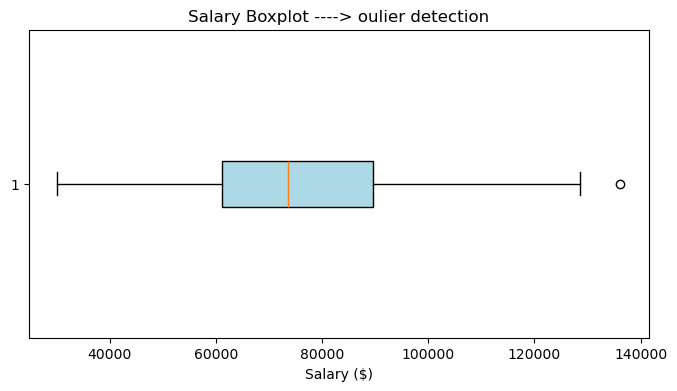

75th percentile: $89575
Employees above 75th percentile: 50


In [12]:
# STEP1. Create a boxplot for Salary to identify outliers.
plt.figure(figsize=(8, 4))
plt.boxplot(df['Salary'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Salary Boxplot ----> oulier detection')
plt.xlabel('Salary ($)')
plt.show() # THE DOT AT THE END INDICATE'S AN OUTLIER.

#STEP2. Calculate how many employees earn above the 75th percentile.
q75 = df['Salary'].quantile(0.75)
above_q75 = (df['Salary']> q75).sum()
print(f"75th percentile: ${q75:.0f}")
print(f"Employees above 75th percentile: {above_q75}")


### Observations --- Part 6:
- The boxplot for 'Salary' indicates a single outlier with a significantly higher salary than the majority of employees. This suggests a potential high-earner who stands apart from the typical salary range in the company.
- The 75th percentile for Salary is $89,575, meaning 25% of employees (50 individuals) earn above this amount, further highlighting the upper end of the salary distribution and the presence of higher-paid positions.

# PART 7: NORMALIZATION AND SCALING

In [13]:
# importing neccessary tools
import sklearn as skl
from sklearn.preprocessing import MinMaxScaler,StandardScaler

sample of original variables vs scaled variables
    Salary  Salary_normalized  Salary_scaled  Bonus %  Bonus %_normalized  \
0  30000.0             0.0000        -2.0340     22.2              0.8816   
1  55200.0             0.2373        -0.8832      9.9              0.3421   
2  72600.0             0.4011        -0.0886     20.9              0.8246   
3  73800.0             0.4124        -0.0338      4.5              0.1053   
4  80700.0             0.4774         0.2813     21.5              0.8509   
5  81700.0             0.4868         0.3270      4.9              0.1228   

   Bonus %_scaled  Year Of Service  Year Of Service_normalized  \
0          1.4453                9                      0.3529   
1         -0.4713               14                      0.6471   
2          1.2428               19                      0.9412   
3         -1.3127                8                      0.2941   
4          1.3362                7                      0.2353   
5         -1.25

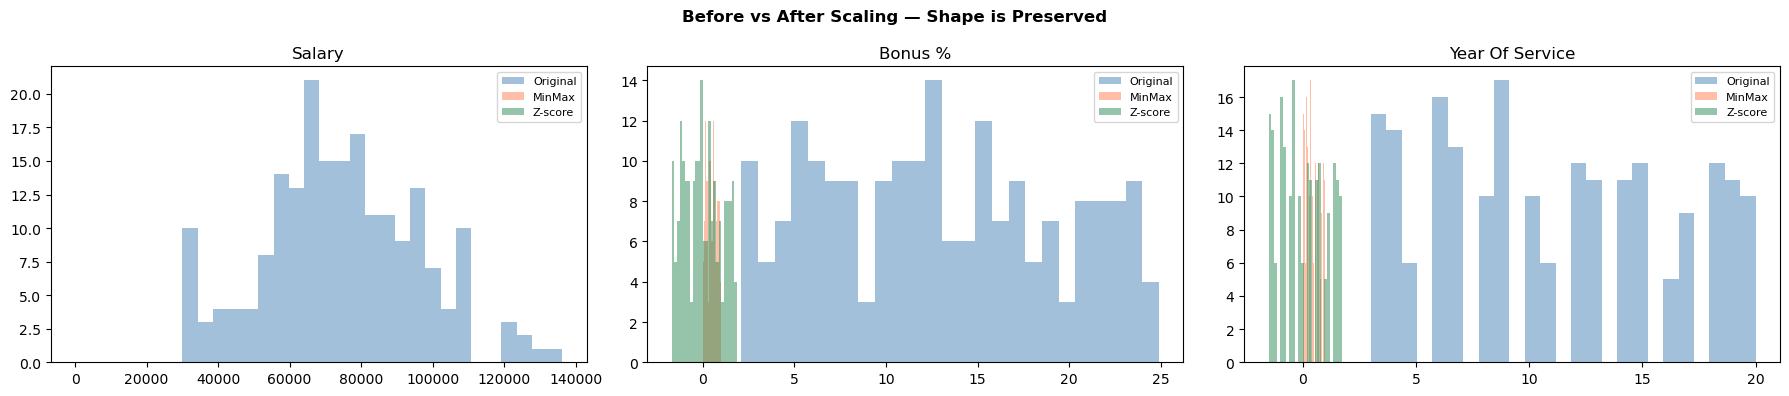

In [14]:
scaler_cols = ['Salary','Bonus %','Year Of Service']
scaler = MinMaxScaler()
std = StandardScaler()
df_scaled = df.copy()
df_scaled[['Salary_normalized','Bonus %_normalized','Year Of Service_normalized']] = scaler.fit_transform(df[scaler_cols])
df_scaled[['Salary_scaled','Bonus %_scaled','Year Of Service_scaled']] = std.fit_transform(df[scaler_cols])


print('sample of original variables vs scaled variables')
print(df_scaled[['Salary','Salary_normalized','Salary_scaled','Bonus %','Bonus %_normalized',
                  'Bonus %_scaled','Year Of Service','Year Of Service_normalized','Year Of Service_scaled']].head(6).round(4))

# Compare distributions before and after scaling using histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col, nc, sc in zip(axes, scaler_cols,
                            ['Salary_normalized', 'Bonus %_normalized', 'Year Of Service_normalized'],
                            ['Salary_scaled',     'Bonus %_scaled',     'Year Of Service_scaled']):
    ax.hist(df[col],       bins=25, alpha=0.5, label='Original', color='steelblue')
    ax.hist(df_scaled[nc], bins=25, alpha=0.5, label='MinMax',   color='coral')
    ax.hist(df_scaled[sc], bins=25, alpha=0.5, label='Z-score',  color='seagreen')
    ax.set_title(col, fontsize=12); ax.legend(fontsize=8)
plt.suptitle('Before vs After Scaling — Shape is Preserved', fontweight='bold')
plt.tight_layout(); plt.show()

# PART 8: INSIGHTS AND ACTIONABLE RECOMMENDATIONS

## Step 1: Insights and Summary

Based on the comprehensive exploratory data analysis (EDA), data cleaning, and feature engineering performed, here are the key findings:

*   **Salary Patterns:** Employee salaries exhibit a wide range, from $30,000 to $136,200, with an average around $74,341. The distribution shows a slight right skew, indicating the presence of a few high-earners. There are notable salary disparities across teams, with HR and Legal teams generally having higher average salaries compared to Marketing and Finance.

*   **Gender Distributions:** The workforce has a slightly higher proportion of male employees compared to female employees, along with a small segment of non-binary and 'unknown' (imputed) genders. Crucially, the average bonus percentages for male and female employees are remarkably similar, suggesting equitable bonus distribution in this regard. However, non-binary and 'unknown' gender categories show slightly lower average bonuses, which warrants further investigation.

*   **Bonus Relationships:** The 'Bonus %' is quite uniformly distributed across its range (2.1% to 24.9%) and shows a very weak correlation with both 'Salary' and 'Year Of Service'. This implies that bonus percentages are not strongly tied to an employee's salary level or their tenure within the company.

*   **Impact of Experience on Salary:** There is a weak positive correlation (0.12) between 'Year Of Service' and 'Salary'. While this suggests that employees with more years of service tend to earn slightly more, the relationship is not strong. This indicates that experience alone is not the primary driver of significant salary increases, and other factors might be more influential.

*   **Outliers:** A single significant outlier with a notably high salary was identified, indicating a top earner who stands apart from the typical salary range.

## Step 2: Actionable Recommendations

Based on the insights gathered, here are actionable recommendations for the company:

1.  **Conduct a Salary Equity Review Across Teams:** Investigate the reasons behind significant average salary differences between teams (e.g., higher in HR/Legal vs. lower in Marketing/Finance). This review should include market benchmarking for roles, an assessment of internal equity, and performance-based compensation structures to ensure fairness and competitiveness across all departments.

2.  **Refine Bonus Compensation Structure:** Given the weak correlation between bonuses, salary, and experience, the company should re-evaluate its bonus policy. Consider aligning bonus criteria more directly with individual performance metrics, team achievements, or overall company profitability to make bonuses a more effective motivational tool and ensure they reward desired outcomes.

3.  **Promote and Monitor Compensation Equity for All Genders:** While average bonuses for male and female employees are similar, closely monitor salary and bonus distributions for non-binary and 'unknown' gender categories. Proactively address any observed disparities to foster an inclusive and equitable compensation environment.

4.  **Develop Clear Career Progression and Development Paths:** The weak link between 'Year Of Service' and 'Salary' suggests that tenure alone may not be translating into significant salary growth. Establish clear career development programs, training opportunities, and defined promotion criteria to provide employees with visible pathways for professional growth and corresponding salary advancement.

5.  **Strategically Leverage High-Performing Roles:** Understand the factors contributing to the high salary of the identified outlier. If this represents a critical, high-impact role, consider developing a strategy to identify and nurture similar talent, ensuring the company can attract and retain individuals in such pivotal positions. This might involve creating specialized compensation packages or retention incentives for key roles.

# PART 9 : BONUS EDA

Salary category distribution
                 count
Salary Category       
Medium             130
Low                 47
High                23


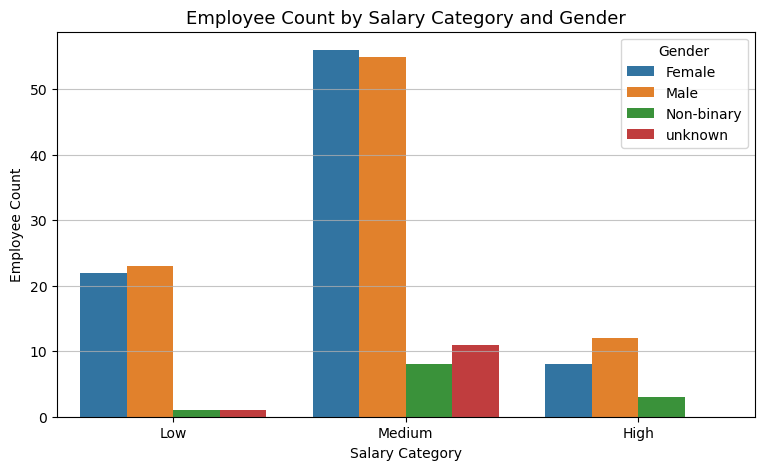

clean employee dataset.csv


In [ ]:
def salary_category(salary):
    if salary < 60000:
        return 'Low'
    elif 60000 <= salary <= 100000:
        return 'Medium'
    else:
        return 'High'
    return
print("Salary category distribution")
df_scaled['Salary Category'] = df_scaled['Salary'].apply(salary_category)
print(df_scaled['Salary Category'].value_counts().to_frame())


# count plot of employees by salary category and gender
plt.figure(figsize=(9, 5))
sns.countplot(data=df_scaled, x='Salary Category', hue='Gender', order=['Low', 'Medium', 'High'])
plt.title('Employee Count by Salary Category and Gender', fontsize=13)
plt.xlabel('Salary Category')
plt.ylabel('Employee Count')
plt.grid(axis='y', alpha=0.75)
plt.show()


**Observations — Part 9:**
- Employees are fairly evenly spread across Low (~25%), Medium (~37%), and High (~38%) salary categories.
- Gender distribution is consistent across all three categories — neither gender is disproportionately concentrated at any salary level.

---

# PART 10 : MACHINE LEARNING ALGORITHM TO PREDICT OR TO CLASSIFY

In [16]:
# PREDICT SENOIR MANAGEMENT
ml_df = df_scaled.copy() # Changed from df.copy() to df_scaled.copy()
ml_df['Gender_enc'] = ml_df['Gender'].cat.codes # enc = encoded
ml_df['Team_enc'] = ml_df['Team'].cat.codes
ml_df['Target'] = ml_df['Senior Management'].astype(int)

# define features and target
features = ['Salary_normalized','Bonus %_normalized','Year Of Service_normalized','Gender_enc','Team_enc']
X = ml_df[features]
y = ml_df['Target']

print("Target distribution")
print(y.value_counts().rename({0:'Not Senoir(0)',1: 'Senoir(1)'}).to_frame())
print()
print("Features used:",features)

# split data into train and test
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier # Added this import statement
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain sample : {len(X_train)}")
print(f"Test sample : {len(X_test)}")

# Train Random Forest
model = RandomForestClassifier(random_state=42, n_estimators = 100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("\nModel training complete")

Target distribution
               count
Target              
Not Senoir(0)    141
Senoir(1)         59

Features used: ['Salary_normalized', 'Bonus %_normalized', 'Year Of Service_normalized', 'Gender_enc', 'Team_enc']

Train sample : 160
Test sample : 40

Model training complete


In [17]:
# PREDICT SENOIR MANAGEMENT
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.dummy import DummyClassifier
ml_df = df_scaled.copy() # Changed from df.copy() to df_scaled.copy()
ml_df['Gender_enc'] = ml_df['Gender'].cat.codes # enc = encoded
ml_df['Team_enc'] = ml_df['Team'].cat.codes
ml_df['Target'] = ml_df['Senior Management'].astype(int)

# define features and target
features = ['Salary_normalized','Bonus %_normalized','Year Of Service_normalized','Gender_enc','Team_enc']
X = ml_df[features]
y = ml_df['Target'] # the target variable to predict

print("Target distribution")
print(y.value_counts().rename({0:'Not Senoir(0)',1: 'Senoir(1)'}).to_frame())
print()
print("Features used:",features)

# split data into train and test
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier # Added this import statement
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"\nTrain sample : {len(X_train)}")
print(f"Test sample : {len(X_test)}")

# Train Random Forest
model = RandomForestClassifier(random_state=42, n_estimators = 100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("\nModel training complete")

Target distribution
               count
Target              
Not Senoir(0)    141
Senoir(1)         59

Features used: ['Salary_normalized', 'Bonus %_normalized', 'Year Of Service_normalized', 'Gender_enc', 'Team_enc']

Train sample : 150
Test sample : 50

Model training complete


# PART 11:MODEL EVALUATION
evaluatin to see the model performance

Baseline Accuracy (majority class): 70.00%
Classification Report:
              precision    recall  f1-score   support

  Not senoir       0.73      0.91      0.81        35
      Senoir       0.50      0.20      0.29        15

    accuracy                           0.70        50
   macro avg       0.61      0.56      0.55        50
weighted avg       0.66      0.70      0.65        50

Random Forest Accuracy: 70.00%


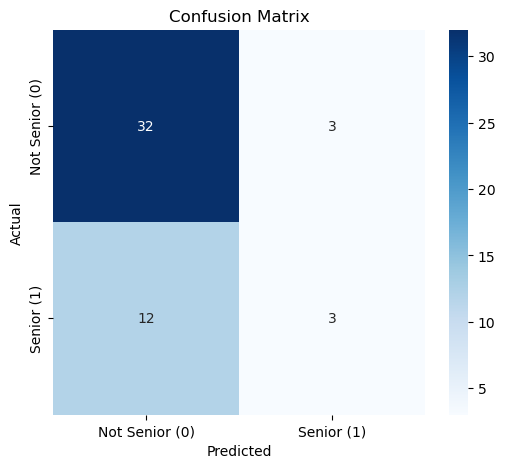

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.dummy import DummyClassifier
# baseline- majority class classifier
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
base_accuracy = baseline.score(X_test, y_test)
print(f"Baseline Accuracy (majority class): {base_accuracy:.2%}")


# Evaluate the model performance
print("Classification Report:")
print(classification_report(y_test, y_pred,target_names=['Not senoir', 'Senoir']))
rf_accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Senior (0)', 'Senior (1)'],
            yticklabels=['Not Senior (0)', 'Senior (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#

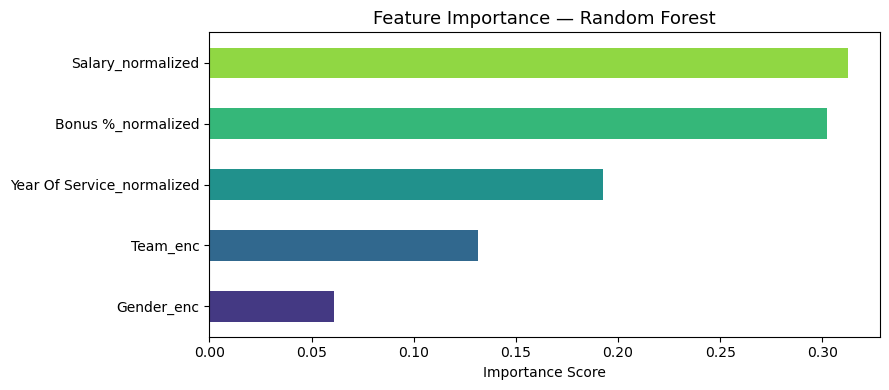

Feature importances (descending):
Salary_normalized             0.3126
Bonus %_normalized            0.3023
Year Of Service_normalized    0.1927
Team_enc                      0.1313
Gender_enc                    0.0611
dtype: float64


In [19]:
# Feature Importance
imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
imp.plot(kind='barh', figsize=(9, 4), color=sns.color_palette('viridis', len(features)))
plt.title('Feature Importance — Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()

print("Feature importances (descending):")
print(imp.sort_values(ascending=False).round(4))

## Model Summary and Interpretation

### Model Performance:
*   **Baseline Accuracy (Majority Class):** The baseline model, which simply predicts the most frequent class, achieved an accuracy of 70.00%. This means that if we always predicted 'Not Senior', we would be correct 70% of the time.
*   **Random Forest Accuracy:** The Random Forest Classifier also achieved an accuracy of 70.00%.

### Interpretation:
*   **No Improvement over Baseline:** The Random Forest model did not outperform the simple majority class baseline. This suggests that the features currently used are not strong predictors of 'Senior Management' status, or the model is not capturing complex relationships effectively given the current data and class imbalance.
*   **Precision and Recall for 'Senior':** The model's precision for predicting 'Senior' (class 1) is 50%, meaning that when it predicts someone is Senior, it's correct only half the time. The recall for 'Senior' is even lower at 20%, indicating that the model only identifies 20% of the actual Senior Managers. This is a significant weakness; the model struggles to correctly identify the 'Senior' class.
*   **Stronger Performance for 'Not Senior':** For the 'Not Senior' class (class 0), the model shows better performance with 73% precision and 91% recall. This is largely due to the class imbalance, where 'Not Senior' is the majority class.

### Feature Importance:
*   **Salary_normalized (0.3126) and Bonus %_normalized (0.3023):** These two features are the most important in the model's decision-making process. This aligns with intuition as salary and bonus can be indicators of seniority.
*   **Year Of Service_normalized (0.1927):** This feature also contributes significantly, suggesting that tenure plays a role, though less than salary and bonus.
*   **Team_enc (0.1313) and Gender_enc (0.0611):** These categorical features have less influence on the model's predictions compared to the numerical ones.

### Conclusion:
While the Random Forest model's overall accuracy matches the baseline, its poor performance in identifying the 'Senior' class highlights that it is not effectively distinguishing between senior and non-senior employees. Further efforts are needed to improve the model, possibly by exploring more relevant features, trying different algorithms, or addressing the class imbalance more explicitly (e.g., using oversampling, undersampling, or different evaluation metrics for imbalanced datasets).